In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv('global_air_quality_dataset.csv')

In [30]:
#first 5 rows
df.head()

,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


#columns and Rows

In [31]:
#columns and Rows Count

print("Rows and Columns:", df.shape)

Rows and Columns: (3660, 13)


In [32]:
#Column Name in Order

print(df.columns)

Index(['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
       'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)',
       'Humidity (%)', 'Wind Speed (m/s)'],
      dtype='object')


In [33]:
# Find Null values

print(df.isnull().sum())

Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64


In [34]:
#Checking Duplicate Values:

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [35]:
# Convert the date column into proper date format, if available


df['Date'] = pd.to_datetime(df['Date'])

In [36]:
#Create year and month columns from the date colum

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [39]:
#Ensure Numerical Format:
numeric_columns = ['AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
       'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)',
       'Humidity (%)', 'Wind Speed (m/s)']

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [40]:
#Creating AQI cATAGORIES:

def categorize_aqi(aqi):

    if aqi <= 50:
        return 'Good'

    elif aqi <= 100:
        return 'Moderate'

    elif aqi <= 150:
        return 'Unhealthy for Sensitive Groups'

    elif aqi <= 200:
        return 'Unhealthy'

    elif aqi <= 300:
        return 'Very Unhealthy'

    else:
        return 'Hazardous'

In [41]:
#Apply Function
df['AQI_Category'] = df['AQI'].apply(categorize_aqi)

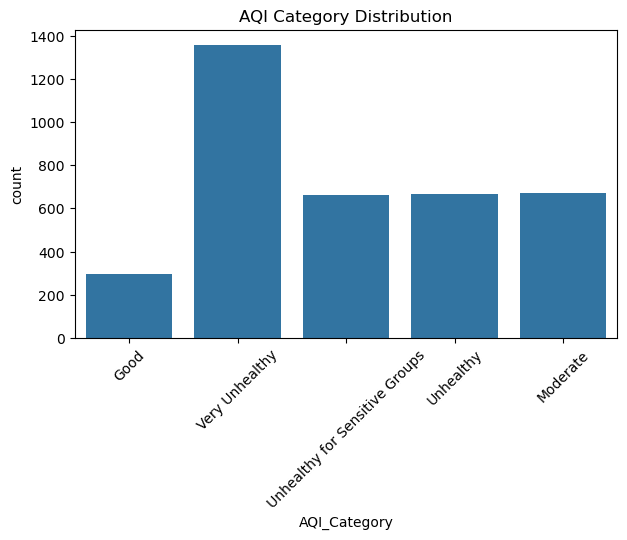

In [43]:
plt.figure(figsize=(7,4))
sns.countplot(x='AQI_Category', data=df)
plt.xticks(rotation=45)
plt.title('AQI Category Distribution')
plt.show()

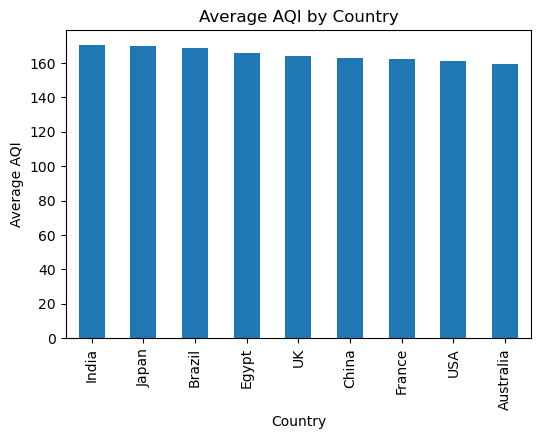

In [42]:
country_aqi = df.groupby('Country')['AQI'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(6,4))
country_aqi.plot(kind='bar')
plt.title('Average AQI by Country')
plt.ylabel('Average AQI')
plt.show()

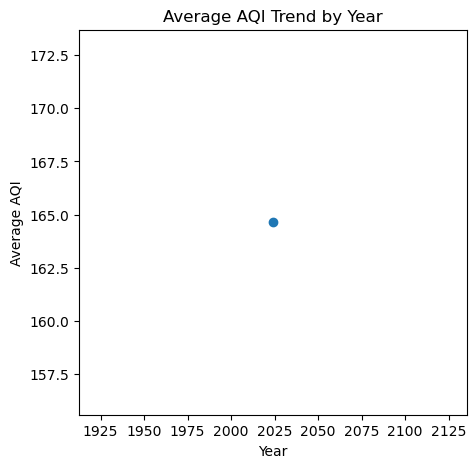

In [44]:
yearly_aqi = df.groupby('Year')['AQI'].mean()
plt.figure(figsize=(5,5))
yearly_aqi.plot(marker='o')
plt.title('Average AQI Trend by Year')
plt.ylabel('Average AQI')
plt.show()

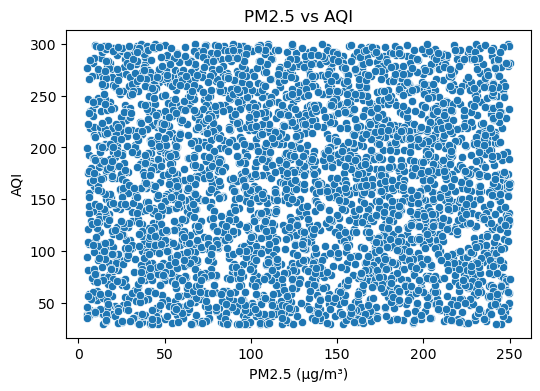

In [45]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='PM2.5 (µg/m³)',
    y='AQI',
    data=df
)
plt.title('PM2.5 vs AQI')
plt.show()

In [46]:
print(df.columns)

Index(['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
       'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)',
       'Humidity (%)', 'Wind Speed (m/s)', 'Year', 'Month', 'AQI_Category'],
      dtype='object')


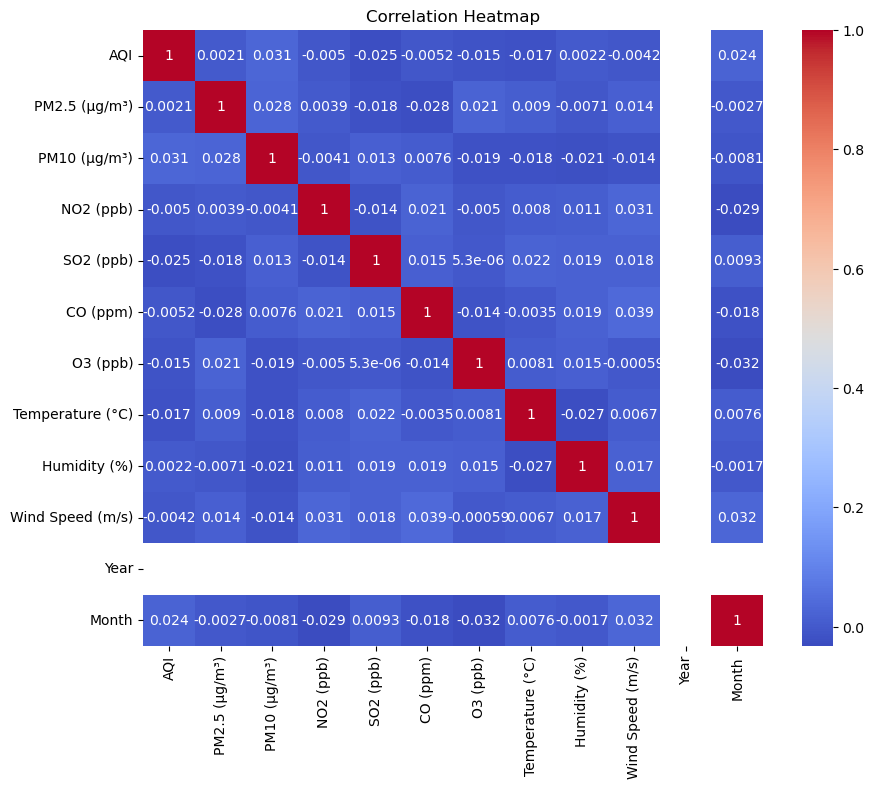

In [47]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()




In [48]:
mean_aqi = df['AQI'].mean()
min_aqi = df['AQI'].min()
max_aqi = df['AQI'].max()
std_aqi = df['AQI'].std()

print("Mean AQI:", mean_aqi)
print("Minimum AQI:", min_aqi)
print("Maximum AQI:", max_aqi)
print("Standard Deviation:", std_aqi)


Mean AQI: 164.64207650273224
Minimum AQI: 30
Maximum AQI: 300
Standard Deviation: 78.57165923842541


In [49]:

print(df.groupby('Country')['AQI'].mean())
highest = df.loc[df['AQI'].idxmax()]


Country
Australia    159.620219
Brazil       168.765027
China        162.953552
Egypt        166.062842
France       162.161202
India        170.581967
Japan        169.598361
UK           163.855191
USA          161.411202
Name: AQI, dtype: float64


In [50]:
lowest = df.loc[df['AQI'].idxmin()]
print("Highest AQI Location")
print(highest[['City','Country','AQI']])

print("Lowest AQI Location")
print(lowest[['City','Country','AQI']])

Highest AQI Location
City       São Paulo
Country       Brazil
AQI              300
Name: 288, dtype: object
Lowest AQI Location
City       Los Angeles
Country            USA
AQI                 30
Name: 91, dtype: object


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

KNN Classification





In [52]:
features = [
    'PM2.5 (µg/m³)',
    'PM10 (µg/m³)',
    'NO2 (ppb)',
    'SO2 (ppb)',
    'CO (ppm)',
    'O3 (ppb)'
]

X = df[features]

y = df['AQI_Category']

In [53]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)

In [54]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [55]:
#train KNN MODEL, K=3

knn3 = KNeighborsClassifier(n_neighbors=3)

knn3.fit(X_train_scaled, y_train)

pred3 = knn3.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred3))

Accuracy: 0.24180327868852458


In [56]:
# K=5

knn5 = KNeighborsClassifier(n_neighbors=5)

knn5.fit(X_train_scaled, y_train)

pred5 = knn5.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred5))

Accuracy: 0.24863387978142076


In [57]:
#K =7
knn7 = KNeighborsClassifier(n_neighbors=7)

knn7.fit(X_train_scaled, y_train)

pred7 = knn7.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred7))

Accuracy: 0.24043715846994534


In [58]:
#confusion_matrix
print(confusion_matrix(y_test, pred5))

[[  4  12   6  11  30]
 [  8  28  28  23  55]
 [  3  16  22  25  48]
 [ 16  32  17  17  48]
 [ 20  56  54  42 111]]


In [59]:
#classification_reports
print(classification_report(y_test, pred5))

                                precision    recall  f1-score   support

                          Good       0.08      0.06      0.07        63
                      Moderate       0.19      0.20      0.20       142
                     Unhealthy       0.17      0.19      0.18       114
Unhealthy for Sensitive Groups       0.14      0.13      0.14       130
                Very Unhealthy       0.38      0.39      0.39       283

                      accuracy                           0.25       732
                     macro avg       0.19      0.20      0.19       732
                  weighted avg       0.24      0.25      0.25       732



In [60]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [61]:
nb_pred = nb.predict(X_test_scaled)

In [62]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.3866120218579235


In [63]:
print(confusion_matrix(y_test, nb_pred))

[[  0   0   0   0  63]
 [  0   0   0   0 142]
 [  0   0   0   0 114]
 [  0   0   0   0 130]
 [  0   0   0   0 283]]


In [64]:
print(classification_report(y_test, nb_pred))

                                precision    recall  f1-score   support

                          Good       0.00      0.00      0.00        63
                      Moderate       0.00      0.00      0.00       142
                     Unhealthy       0.00      0.00      0.00       114
Unhealthy for Sensitive Groups       0.00      0.00      0.00       130
                Very Unhealthy       0.39      1.00      0.56       283

                      accuracy                           0.39       732
                     macro avg       0.08      0.20      0.11       732
                  weighted avg       0.15      0.39      0.22       732



C:\Users\rzkha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rzkha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rzkha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [65]:
cluster_data = df[features]

In [66]:
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

In [67]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(cluster_scaled)

df['Cluster'] = clusters


In [71]:
cluster_summary = df.groupby('Cluster')[['AQI','PM2.5 (µg/m³)']].mean()

print(cluster_summary)

                AQI  PM2.5 (µg/m³)
Cluster                           
0        166.117994     114.658333
1        161.940754      65.814991
2        165.489076     196.435546


In [72]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(cluster_scaled)

In [73]:
pca_df = pd.DataFrame()

pca_df['PC1'] = pca_result[:,0]

pca_df['PC2'] = pca_result[:,1]

pca_df['Cluster'] = df['Cluster']

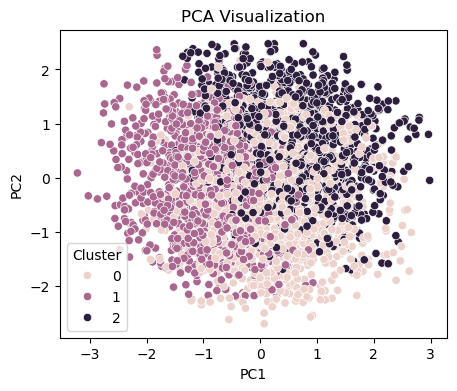

In [77]:
plt.figure(figsize=(5,4))
sns.scatterplot( x='PC1', y='PC2', hue='Cluster', data=pca_df)
plt.title('PCA Visualization')
plt.show()

In [79]:
print(pca.explained_variance_ratio_) 


[0.17523258 0.17091781]
